**0temp.tsv**: contains only single point mutations (2531 rows)

**1temp.tsv**: contains all ProThermDB entries w/ $\Delta\Delta G$ values (3949 rows, not included in repo)

## 1. Filter ProTherm for single point mutations
Some of the structures include mutation information relative to the UniProt ID (e.g. D44N), while some have a PDB ID for the WT and mutant proteins. I'll extract these columns (along with the $\Delta\Delta G$ values) and figure out which mutants have which type of information.

In [ ]:
import pandas as pd

file = '0temp.tsv'  # TODO: rename to something less silly
table = pd.read_csv(file, sep='\t')

table.head()

,NO,PROTEIN,UniProt_ID,MUTATION,SOURCE,PDB_wild,PDB_Chain_Mutation,SEC_STR,ASA,pH,T_(C),∆∆G_(kcal/mol),∆∆G_H2O_(kcal/mol),STATE,REVERSIBILITY,PubMed_ID,KEY_WORDS,REFERENCE,AUTHOR
0,176,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.73,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
1,177,Villin-1,P02640,E795Q (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.9,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
2,178,Villin-1,P02640,D796N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.61,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
3,179,Villin-1,P02640,E822Q (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.6,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
4,181,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,6.0,-,-0.46,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"


In [2]:
# remove unnecessary columns for now
table = table.iloc[:, [1, 2, 3, 4, 5, 6, 9, 11]]

In [3]:
# keep only structures that have either a UniProt or PDB mutation
table['TYPE'] = ['PDB' if 'PDB' in x else 'UniProt' if 'UniProt' in x else 'Unknown' for x in table['MUTATION']]
table = table[table['TYPE'] != 'Unknown']

In [4]:
table.dropna(subset=['∆∆G_(kcal/mol)'], inplace=True)

In [5]:
table.head()  # final table

,PROTEIN,UniProt_ID,MUTATION,SOURCE,PDB_wild,PDB_Chain_Mutation,pH,∆∆G_(kcal/mol),TYPE
0,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,3.0,1.73,UniProt
1,Villin-1,P02640,E795Q (UniProt),Gallus gallus (Chicken),1YRF,-,3.0,1.9,UniProt
2,Villin-1,P02640,D796N (UniProt),Gallus gallus (Chicken),1YRF,-,3.0,1.61,UniProt
3,Villin-1,P02640,E822Q (UniProt),Gallus gallus (Chicken),1YRF,-,3.0,1.6,UniProt
4,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,6.0,-0.46,UniProt


In [6]:
table.shape  # dimensions after filtering

(2320, 9)

In [7]:
table_uniprot = table[table['TYPE'] == 'UniProt']
table_pdb = table[table['TYPE'] == 'PDB']

In [8]:
table_uniprot.shape

(511, 9)

In [9]:
table_pdb.shape

(1809, 9)

## 2. Baseline Model

### Preprocess data for XGBoost

In [10]:
# copied from claude for now, no idea where it's getting these from
# TODO: find correct values
aa_properties = {
    'A': {'hydrophobicity': 1.8, 'charge': 0, 'weight': 89.1},
    'R': {'hydrophobicity': -4.5, 'charge': 1, 'weight': 174.2},
    'N': {'hydrophobicity': -3.5, 'charge': 0, 'weight': 132.1},
    'D': {'hydrophobicity': -3.5, 'charge': -1, 'weight': 133.1},
    'C': {'hydrophobicity': 2.5, 'charge': 0, 'weight': 121.2},
    'Q': {'hydrophobicity': -3.5, 'charge': 0, 'weight': 146.2},
    'E': {'hydrophobicity': -3.5, 'charge': -1, 'weight': 147.1},
    'G': {'hydrophobicity': -0.4, 'charge': 0, 'weight': 75.0},
    'H': {'hydrophobicity': -3.2, 'charge': 0, 'weight': 155.2},
    'I': {'hydrophobicity': 4.5, 'charge': 0, 'weight': 131.2},
    'L': {'hydrophobicity': 3.8, 'charge': 0, 'weight': 131.2},
    'K': {'hydrophobicity': -3.9, 'charge': 1, 'weight': 146.2},
    'M': {'hydrophobicity': 1.9, 'charge': 0, 'weight': 149.2},
    'F': {'hydrophobicity': 2.8, 'charge': 0, 'weight': 165.2},
    'P': {'hydrophobicity': -1.6, 'charge': 0, 'weight': 115.1},
    'S': {'hydrophobicity': -0.8, 'charge': 0, 'weight': 105.1},
    'T': {'hydrophobicity': -0.7, 'charge': 0, 'weight': 119.1},
    'W': {'hydrophobicity': -0.9, 'charge': 0, 'weight': 204.2},
    'Y': {'hydrophobicity': -1.3, 'charge': 0, 'weight': 181.2},
    'V': {'hydrophobicity': 4.2, 'charge': 0, 'weight': 117.1}
}

In [11]:
# work with only UniProt mutations for now
table_uniprot_xgb = table_uniprot.copy()  # don't touch original table
table_uniprot_xgb['WT_AA'] = table_uniprot_xgb['MUTATION'].apply(lambda x: x.split()[0][0])
table_uniprot_xgb['MUT_AA'] = table_uniprot_xgb['MUTATION'].apply(lambda x: x.split()[0][-1])
table_uniprot_xgb['POSITION'] = table_uniprot_xgb['MUTATION'].apply(lambda x: int(x.split()[0][1:-1]))

In [12]:
# drop some unnecessary columns 
table_uniprot_xgb.drop(columns=['MUTATION', 'TYPE', 'PDB_Chain_Mutation'], inplace=True)

In [13]:
table_uniprot_xgb.head()

,PROTEIN,UniProt_ID,SOURCE,PDB_wild,pH,∆∆G_(kcal/mol),WT_AA,MUT_AA,POSITION
0,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.73,D,N,44
1,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.9,E,Q,795
2,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.61,D,N,796
3,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.6,E,Q,822
4,Villin-1,P02640,Gallus gallus (Chicken),1YRF,6.0,-0.46,D,N,44


In [14]:
# calculate changes in hydrophobicity, charge, and weight for each mutation
table_uniprot_xgb['delta_hydrophobicity'] = table_uniprot_xgb.apply(lambda row: aa_properties[row['MUT_AA']]['hydrophobicity'] - aa_properties[row['WT_AA']]['hydrophobicity'], axis=1)
table_uniprot_xgb['delta_charge'] = table_uniprot_xgb.apply(lambda row: aa_properties[row['MUT_AA']]['charge'] - aa_properties[row['WT_AA']]['charge'], axis=1)
table_uniprot_xgb['delta_weight'] = table_uniprot_xgb.apply(lambda row: aa_properties[row['MUT_AA']]['weight'] - aa_properties[row['WT_AA']]['weight'], axis=1)

In [ ]:
table_uniprot_xgb.head()  # final XGBoost table

,PROTEIN,UniProt_ID,SOURCE,PDB_wild,pH,∆∆G_(kcal/mol),WT_AA,MUT_AA,POSITION,delta_hydrophobicity,delta_charge,delta_weight
0,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.73,D,N,44,0.0,1,-1.0
1,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.9,E,Q,795,0.0,1,-0.9
2,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.61,D,N,796,0.0,1,-1.0
3,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.6,E,Q,822,0.0,1,-0.9
4,Villin-1,P02640,Gallus gallus (Chicken),1YRF,6.0,-0.46,D,N,44,0.0,1,-1.0


In [16]:
# train/test split (80/20)
table_uniprot_xgb_shuffled = table_uniprot_xgb.sample(frac=1, random_state=42).reset_index(drop=True)
train_size = int(0.8 * len(table_uniprot_xgb_shuffled))
train_data_xgb = table_uniprot_xgb_shuffled.iloc[:train_size]
test_data_xgb = table_uniprot_xgb_shuffled.iloc[train_size:]

In [17]:
len(train_data_xgb), len(test_data_xgb)

(408, 103)

In [18]:
# split into features and labels
X_train_xgb = train_data_xgb.drop(columns=['∆∆G_(kcal/mol)'])
y_train_xgb = train_data_xgb['∆∆G_(kcal/mol)']

X_test_xgb = test_data_xgb.drop(columns=['∆∆G_(kcal/mol)'])
y_test_xgb = test_data_xgb['∆∆G_(kcal/mol)']

## 3. Implement baseline model (XGBoost)

## 4. (GNN) Map each entry to AlphaFold using UniProt/PDB IDs

Get WT and mutant structures for each protein. WT structures can be directly obtained from PDB/UniProt IDs. For the mutations that have their own PDB structures, we can use those directly. For the others, we have a UniProt ID and a specific mutation, and we can use AlphaFold to make a prediction for what the mutant structure will be.

## 5. (GNN) Build residue contact graph

Supposedly, the `graphein` library can take a PDB or AlphaFold structure and automatically generate a graph. Ask if this is ok???

In [19]:
# ! pip install graphein

In [20]:
# no idea how to use this btw
# unsure what features each node stores

from graphein.protein.config import ProteinGraphConfig
from graphein.protein.graphs import construct_graph
from graphein.protein.utils import download_alphafold_structure

config = ProteinGraphConfig()
# fp = download_alphafold_structure("Q5VSL9", aligned_score=False)
g = construct_graph(config=config, pdb_code='3eiy')

C:\Users\amyac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\amyac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\amyac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\amyac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

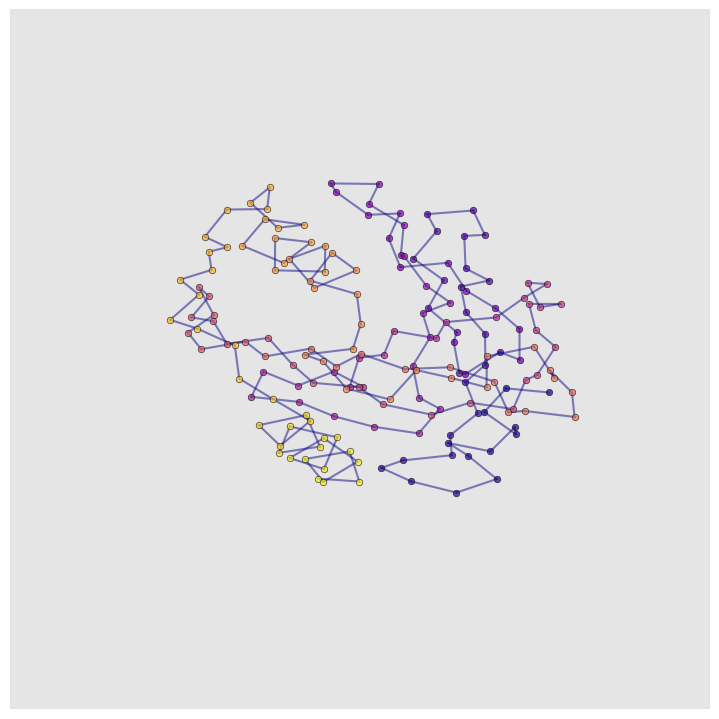

In [21]:
from graphein.protein.visualisation import plot_protein_structure_graph

# graph
p = plot_protein_structure_graph(G=g, angle=0, colour_edges_by="kind", colour_nodes_by="seq_position", label_node_ids=False)

In [22]:
# TODO (for GNN):
# - download all pdbs for WT structures and PDB mutants
#   - can use requests/urllib to download all pdbs, the issue will be parsing them
# - look into alphafold's api for predicting structures for UniProt mutants
# - from what i've read, i believe alphafold returns a .pdb file as well?
# - next issue will be parsing pdb files and turning them into graphs
# - graphein to create graphs? BioPython and ProDy both have pdb parsers?